# Data Preparation Pipeline


In [6]:
from db.core import db_to_csv

db_to_csv()

2026-05-07 00:09:27.664 | INFO     | db.core:db_to_csv:72 - Таблица gold_cost экспортирована в CSV.
2026-05-07 00:09:27.705 | INFO     | db.core:db_to_csv:72 - Таблица sliver_cost экспортирована в CSV.
2026-05-07 00:09:27.732 | INFO     | db.core:db_to_csv:72 - Таблица copper_cost экспортирована в CSV.
2026-05-07 00:09:27.826 | INFO     | db.core:db_to_csv:72 - Таблица gold_news экспортирована в CSV.
2026-05-07 00:09:27.865 | INFO     | db.core:db_to_csv:72 - Таблица sliver_news экспортирована в CSV.
2026-05-07 00:09:27.897 | INFO     | db.core:db_to_csv:72 - Таблица copper_news экспортирована в CSV.
2026-05-07 00:09:27.922 | INFO     | db.core:db_to_csv:72 - Таблица gold_predict_cost экспортирована в CSV.
2026-05-07 00:09:27.954 | INFO     | db.core:db_to_csv:72 - Таблица users экспортирована в CSV.
2026-05-07 00:09:28.010 | INFO     | db.core:db_to_csv:72 - Таблица demo_trades экспортирована в CSV.
2026-05-07 00:09:28.049 | INFO     | db.core:db_to_csv:72 - Таблица sliver_predict_cos

In [7]:
import random
from pathlib import Path
import pickle
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import set_random_seed

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
set_random_seed(SEED)


def load_and_prepare_dataset(metal_name, history_years=2):
    """Builds a combined dataset from prices and news for the selected metal."""
    cost_file = Path(f"data/{metal_name}_cost.csv")
    news_file = Path(f"data/{metal_name}_news.csv")

    df_cost = pd.read_csv(cost_file)
    df_cost["date"] = pd.to_datetime(df_cost["date"]).dt.date

    if history_years is not None:
        max_cost_date = pd.to_datetime(df_cost["date"].max())
        cutoff_date = (max_cost_date - pd.DateOffset(years=history_years)).date()
        df_cost = df_cost[df_cost["date"] >= cutoff_date].copy()

    group_cols = ["open", "high", "low", "close"]
    if "volume" in df_cost.columns:
        group_cols.append("volume")
    agg_dict = {col: "mean" for col in group_cols}
    df_cost = df_cost.sort_values("date").groupby("date", as_index=False).agg(agg_dict)

    if "volume" not in df_cost.columns:
        df_cost["volume"] = 0.0

    df_cost["hl_range"] = df_cost["high"] - df_cost["low"]
    df_cost["oc_change"] = df_cost["close"] - df_cost["open"]
    df_cost["close_return"] = df_cost["close"].pct_change().replace([np.inf, -np.inf], 0).fillna(0)
    df_cost["close_return_3"] = df_cost["close"].pct_change(3).replace([np.inf, -np.inf], 0).fillna(0)
    df_cost["close_return_5"] = df_cost["close"].pct_change(5).replace([np.inf, -np.inf], 0).fillna(0)
    df_cost["ma_close_5"] = df_cost["close"].rolling(5).mean()
    df_cost["ma_close_10"] = df_cost["close"].rolling(10).mean()
    df_cost["ma_close_20"] = df_cost["close"].rolling(20).mean()
    df_cost["volatility_5"] = df_cost["close"].pct_change().rolling(5).std()
    df_cost["volatility_10"] = df_cost["close"].pct_change().rolling(10).std()

    df_news = pd.read_csv(news_file)
    df_news["date"] = pd.to_datetime(df_news["date"]).dt.date
    df_news = df_news.sort_values("date").copy()

    if history_years is not None and not df_news.empty:
        cutoff_dt = pd.to_datetime(df_cost["date"].min())
        df_news = df_news[pd.to_datetime(df_news["date"]) >= cutoff_dt].copy()

    pipeline_svm = joblib.load("predict_model/models/svm_sentiment_pipeline.pkl")
    df_news = df_news.dropna(subset=["full_text"]).copy()
    sentiments = pipeline_svm.predict(df_news["full_text"].astype(str))
    sentiment_map = {0: -1, 1: 0, 2: 1}
    df_news["sentiment"] = pd.Series(sentiments).map(sentiment_map).astype(int)

    daily_sentiment = (
        df_news.groupby("date")["sentiment"]
        .sum()
        .clip(-1, 1)
        .reset_index()
    )

    df_combined = pd.merge(df_cost, daily_sentiment, on="date", how="left")
    df_combined["sentiment"] = df_combined["sentiment"].fillna(0).astype(int)
    df_combined["sentiment_ma_3"] = df_combined["sentiment"].rolling(3).mean()
    df_combined["sentiment_ma_7"] = df_combined["sentiment"].rolling(7).mean()
    df_combined["price_momentum_5"] = df_combined["close"].pct_change(5).replace([np.inf, -np.inf], 0).fillna(0)
    df_combined["price_momentum_10"] = df_combined["close"].pct_change(10).replace([np.inf, -np.inf], 0).fillna(0)
    df_combined[["ma_close_5", "ma_close_10", "volatility_5"]] = (
        df_combined[["ma_close_5", "ma_close_10", "volatility_5"]]
        .bfill()
        .ffill()
        .fillna(0)
    )
    df_combined[["ma_close_20", "volatility_10", "sentiment_ma_3", "sentiment_ma_7"]] = (
        df_combined[["ma_close_20", "volatility_10", "sentiment_ma_3", "sentiment_ma_7"]]
        .bfill()
        .ffill()
        .fillna(0)
    )

    df_combined = df_combined.sort_values("date").set_index("date")
    return df_combined


# Load gold dataset (last 2 years)
df_gold = load_and_prepare_dataset("gold", history_years=2)
display(df_gold.head())

,open,high,low,close,volume,hl_range,oc_change,close_return,close_return_3,close_return_5,ma_close_5,ma_close_10,ma_close_20,volatility_5,volatility_10,sentiment,sentiment_ma_3,sentiment_ma_7,price_momentum_5,price_momentum_10
date,,,,,,,,,,,,,,,,,,,,
2024-04-10,7095.0,7159.0,7053.5,7118.7,89640.0,105.5,23.7,0.000000,0.000000,0.0,7166.1,7107.03,6961.95,0.020647,0.016614,0,0.000000,0.142857,0.0,0.0
2024-04-11,7118.7,7139.0,7057.0,7085.0,70306.0,82.0,-33.7,-0.004734,0.000000,0.0,7166.1,7107.03,6961.95,0.020647,0.016614,0,0.000000,0.142857,0.0,0.0
2024-04-12,7145.1,7488.1,7121.1,7265.3,141970.0,367.0,120.2,0.025448,0.000000,0.0,7166.1,7107.03,6961.95,0.020647,0.016614,0,0.000000,0.142857,0.0,0.0
2024-04-15,7200.0,7217.9,7012.0,7099.4,124914.0,205.9,-100.6,-0.022835,-0.002711,0.0,7166.1,7107.03,6961.95,0.020647,0.016614,0,0.000000,0.142857,0.0,0.0
2024-04-16,7158.0,7277.9,7117.1,7262.1,79518.0,160.8,104.1,0.022917,0.024996,0.0,7166.1,7107.03,6961.95,0.020647,0.016614,1,0.333333,0.142857,0.0,0.0


# LSTM Training on Price + Sentiment Data

In [8]:
def train_lstm_pipeline(df, metal_name, timesteps=45, horizon=5, history_years=2):
    feature_columns = [
        "open", "high", "low", "close", "volume", "sentiment",
        "hl_range", "oc_change", "close_return", "close_return_3", "close_return_5",
        "ma_close_5", "ma_close_10", "ma_close_20", "volatility_5", "volatility_10",
        "price_momentum_5", "price_momentum_10", "sentiment_ma_3", "sentiment_ma_7"
    ]
    target_columns = ["open", "high", "low", "close"]
    data = df[target_columns + feature_columns[4:]].sort_index().dropna().copy()

    test_size = 60
    val_size = max(int(len(data) * 0.15), timesteps)
    if len(data) <= test_size + val_size + timesteps + horizon:
        raise ValueError(f"Not enough data for train/val/test split: {len(data)} rows.")

    test_start = len(data) - test_size
    train_end = test_start - val_size

    x_scaler = RobustScaler(quantile_range=(10.0, 90.0))
    x_scaler.fit(data.iloc[:train_end][feature_columns])

    x_scaled_all = pd.DataFrame(
        x_scaler.transform(data[feature_columns]),
        columns=feature_columns,
        index=data.index
    )

    def make_sequences(x_frame, y_frame, timesteps, target_start, target_end, horizon):
        X, y, base_prices, dates = [], [], [], []
        x_values = x_frame.values
        y_values = y_frame.values
        index_values = x_frame.index.to_list()

        for target_idx in range(target_start, target_end):
            start_idx = target_idx - timesteps
            if start_idx < 0 or (target_idx + horizon) > len(y_values):
                continue

            base = y_values[target_idx - 1]
            future = y_values[target_idx:target_idx + horizon]
            rel_future = (future - base) / np.where(base == 0, 1.0, base)

            X.append(x_values[start_idx:target_idx])
            y.append(rel_future)
            base_prices.append(base)
            dates.append(index_values[target_idx + horizon - 1])

        return np.array(X), np.array(y), np.array(base_prices), pd.to_datetime(dates)

    X_train, y_train, base_train, _ = make_sequences(
        x_scaled_all.iloc[:train_end],
        data[target_columns].iloc[:train_end],
        timesteps,
        timesteps,
        train_end - horizon + 1,
        horizon
    )
    X_val, y_val, base_val, _ = make_sequences(
        x_scaled_all.iloc[:test_start],
        data[target_columns].iloc[:test_start],
        timesteps,
        train_end,
        test_start - horizon + 1,
        horizon
    )
    X_test, y_test, base_test, test_dates = make_sequences(
        x_scaled_all,
        data[target_columns],
        timesteps,
        test_start,
        len(data) - horizon + 1,
        horizon
    )

    num_targets = len(target_columns)
    y_scaler = RobustScaler(quantile_range=(10.0, 90.0))
    y_scaler.fit(y_train.reshape(-1, num_targets))

    y_train = y_scaler.transform(y_train.reshape(-1, num_targets)).reshape(len(y_train), horizon * num_targets)
    y_val = y_scaler.transform(y_val.reshape(-1, num_targets)).reshape(len(y_val), horizon * num_targets)
    y_test = y_scaler.transform(y_test.reshape(-1, num_targets)).reshape(len(y_test), horizon * num_targets)

    model = Sequential([
        LSTM(128, input_shape=(timesteps, len(feature_columns)), return_sequences=True),
        Dropout(0.20),
        LSTM(128, return_sequences=True),
        Dropout(0.15),
        LSTM(64, return_sequences=False),
        Dropout(0.10),
        Dense(64, activation="relu"),
        Dense(horizon * num_targets)
    ])

    optimizer = Adam(learning_rate=0.0005, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=Huber(delta=1.0), metrics=["mae"])

    early_stop = EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=0.00001)

    print(f"Training LSTM for {metal_name} (horizon={horizon})...")
    history = model.fit(
        X_train,
        y_train,
        epochs=220,
        batch_size=16,
        validation_data=(X_val, y_val),
        callbacks=[early_stop, reduce_lr],
        shuffle=False,
        verbose=1
    )

    save_dir = Path("predict_model/models")
    save_dir.mkdir(parents=True, exist_ok=True)
    bundle = {
        "model_json": model.to_json(),
        "model_weights": model.get_weights(),
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "timesteps": timesteps,
        "horizon": horizon,
        "history_years": history_years,
        "feature_columns": feature_columns,
        "target_columns": target_columns,
        "train_end_date": str(data.index[train_end - 1]),
        "val_end_date": str(data.index[test_start - 1]),
        "test_start_date": str(data.index[test_start])
    }

    bundle_path = save_dir / f"{metal_name}_lstm_bundle.pkl"
    with open(bundle_path, "wb") as f:
        pickle.dump(bundle, f)

    # Also save Keras weights and full model for convenience
    try:
        weights_path = save_dir / f"{metal_name}_lstm_weights.h5"
        model.save_weights(weights_path, save_format="h5")
        # save full model (TensorFlow SavedModel format) into a subfolder
        full_model_dir = save_dir / f"{metal_name}_lstm_model"
        model.save(full_model_dir, save_format="tf")
        print(f"Keras weights saved to {weights_path}")
        print(f"Full Keras model saved to {full_model_dir}")
    except Exception as e:
        print(f"Warning: failed to save keras model/weights: {e}")

    print(f"Model saved to {bundle_path}")
    return model, history, x_scaler, y_scaler, X_test, y_test, base_test, test_dates, target_columns, horizon


# Train LSTM models for multiple metals (gold, silver, copper)
metals = ["gold", "sliver", "copper"]
trained_models = {}
for metal in metals:
    try:
        print(f"\nTraining LSTM for {metal} (last 2 years)...")
        df_metal = load_and_prepare_dataset(metal, history_years=2)
        model, history, x_scaler, y_scaler, X_test, y_test, base_test, test_dates, target_columns, horizon = train_lstm_pipeline(
            df_metal, metal, horizon=5, history_years=2
        )
        trained_models[metal] = {
            "model": model,
            "history": history,
            "x_scaler": x_scaler,
            "y_scaler": y_scaler,
            "X_test": X_test,
            "y_test": y_test,
            "base_test": base_test,
            "test_dates": test_dates,
            "target_columns": target_columns,
            "horizon": horizon,
        }
    except Exception as e:
        print(f"Failed to train for {metal}: {e}")


Training LSTM for gold (last 2 years)...
Training LSTM for gold (horizon=5)...
Epoch 1/220


D:\SUAI\Diplom\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.0874 - mae: 0.3212 - val_loss: 0.1661 - val_mae: 0.4505 - learning_rate: 5.0000e-04
Epoch 2/220
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0851 - mae: 0.3158 - val_loss: 0.1710 - val_mae: 0.4581 - learning_rate: 5.0000e-04
Epoch 3/220
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0840 - mae: 0.3153 - val_loss: 0.1828 - val_mae: 0.4818 - learning_rate: 5.0000e-04
Epoch 4/220
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0812 - mae: 0.3100 - val_loss: 0.2082 - val_mae: 0.5226 - learning_rate: 5.0000e-04
Epoch 5/220
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0779 - mae: 0.3037 - val_loss: 0.1955 - val_mae: 0.5050 - learning_rate: 5.0000e-04
Epoch 6/220
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0789 - mae: 0.3048 - val_loss: 0.2115 - val_mae: 0.5250 - learning_rate: 5.0000e-04
Epoch 7/220
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0792 - mae: 0.3018 - val_loss: 0.2433 - val_mae: 0.5742 - learning_rate: 5

D:\SUAI\Diplom\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 0.1076 - mae: 0.3293 - val_loss: 0.5992 - val_mae: 0.9856 - learning_rate: 5.0000e-04
Epoch 2/220
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.1060 - mae: 0.3276 - val_loss: 0.6048 - val_mae: 0.9920 - learning_rate: 5.0000e-04
Epoch 3/220
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.1045 - mae: 0.3245 - val_loss: 0.6182 - val_mae: 1.0080 - learning_rate: 5.0000e-04
Epoch 4/220
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1022 - mae: 0.3217 - val_loss: 0.6552 - val_mae: 1.0533 - learning_rate: 5.0000e-04
Epoch 5/220
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0998 - mae: 0.3181 - val_loss: 0.6671 - val_mae: 1.0640 - learning_rate: 5.0000e-04
Epoch 6/220
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0970 - mae: 0.3149 - val_loss: 0.6914 - val_mae: 1.0946 - learning_rate: 5.0000e-04
Epoch 7/220
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0946 - mae: 0.3101 - val_loss: 0.6867 - val_mae: 1.0864 - learning_rate: 5

D:\SUAI\Diplom\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.0751 - mae: 0.3075 - val_loss: 0.2655 - val_mae: 0.5588 - learning_rate: 5.0000e-04
Epoch 2/220
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.0741 - mae: 0.3068 - val_loss: 0.2650 - val_mae: 0.5582 - learning_rate: 5.0000e-04
Epoch 3/220
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.0732 - mae: 0.3056 - val_loss: 0.2638 - val_mae: 0.5567 - learning_rate: 5.0000e-04
Epoch 4/220
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0726 - mae: 0.3055 - val_loss: 0.2627 - val_mae: 0.5551 - learning_rate: 5.0000e-04
Epoch 5/220
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 0.0721 - mae: 0.3046 - val_loss: 0.2617 - val_mae: 0.5539 - learning_rate: 5.0000e-04
Epoch 6/220
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.0713 - mae: 0.3041 - val_loss: 0.2606 - val_mae: 0.5529 - learning_rate: 5.0000e-04
Epoch 7/220
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.0710 - mae: 0.3040 - val_loss: 0.2597 - val_mae: 0.5520 - learning_rate: 5.0000e-04


# Results and Visualization


--- Results for GOLD ---
Test metrics at +5 day horizon:
open   | MAE: 477.8104 | RMSE: 636.8055 | R2: -0.4286 | Naive MAE: 477.1304 | Bias:  -7.7753
high   | MAE: 482.2233 | RMSE: 632.3649 | R2: -0.4813 | Naive MAE: 448.7357 | Bias: -160.8022
low    | MAE: 519.2653 | RMSE: 637.3522 | R2: -0.4191 | Naive MAE: 473.6357 | Bias: -165.0409
close  | MAE: 507.2484 | RMSE: 635.1347 | R2: -0.5253 | Naive MAE: 475.6482 | Bias: -164.4527


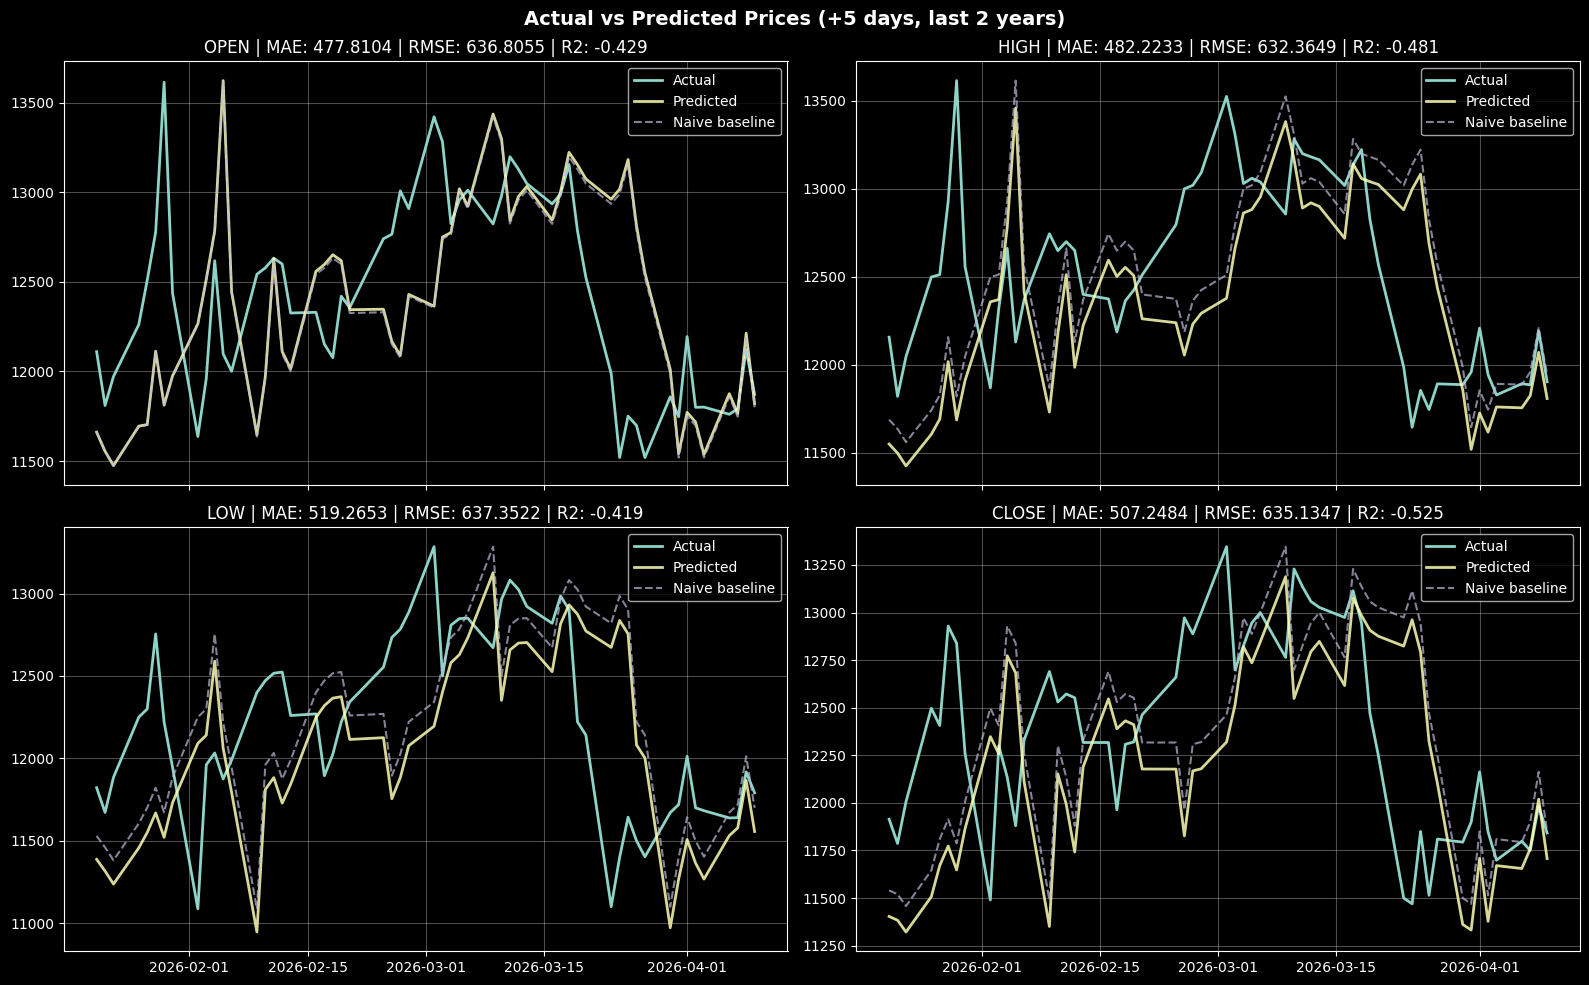

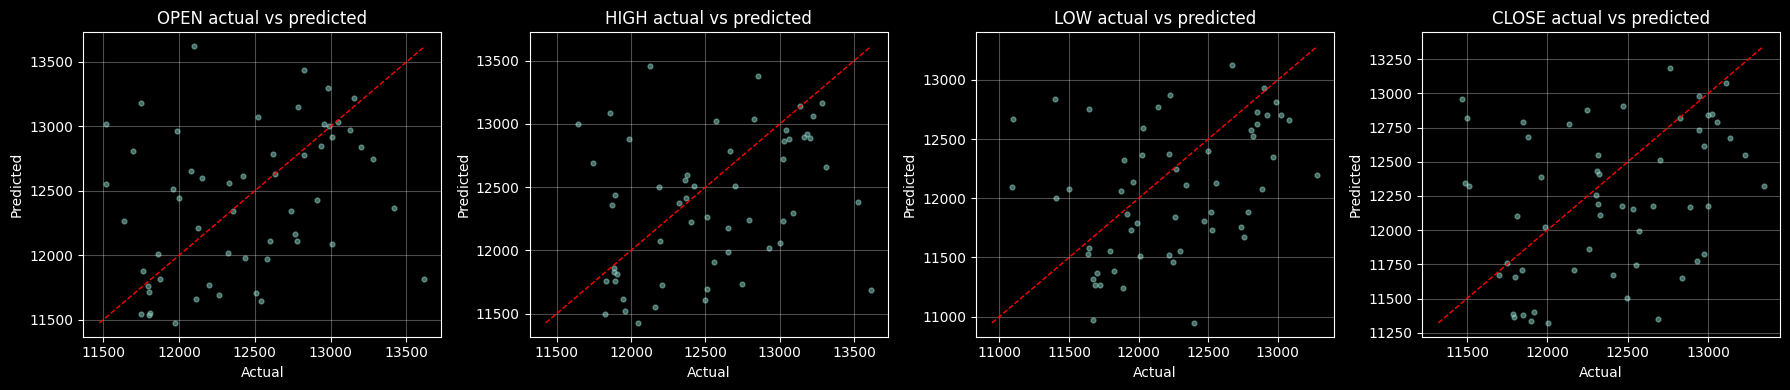

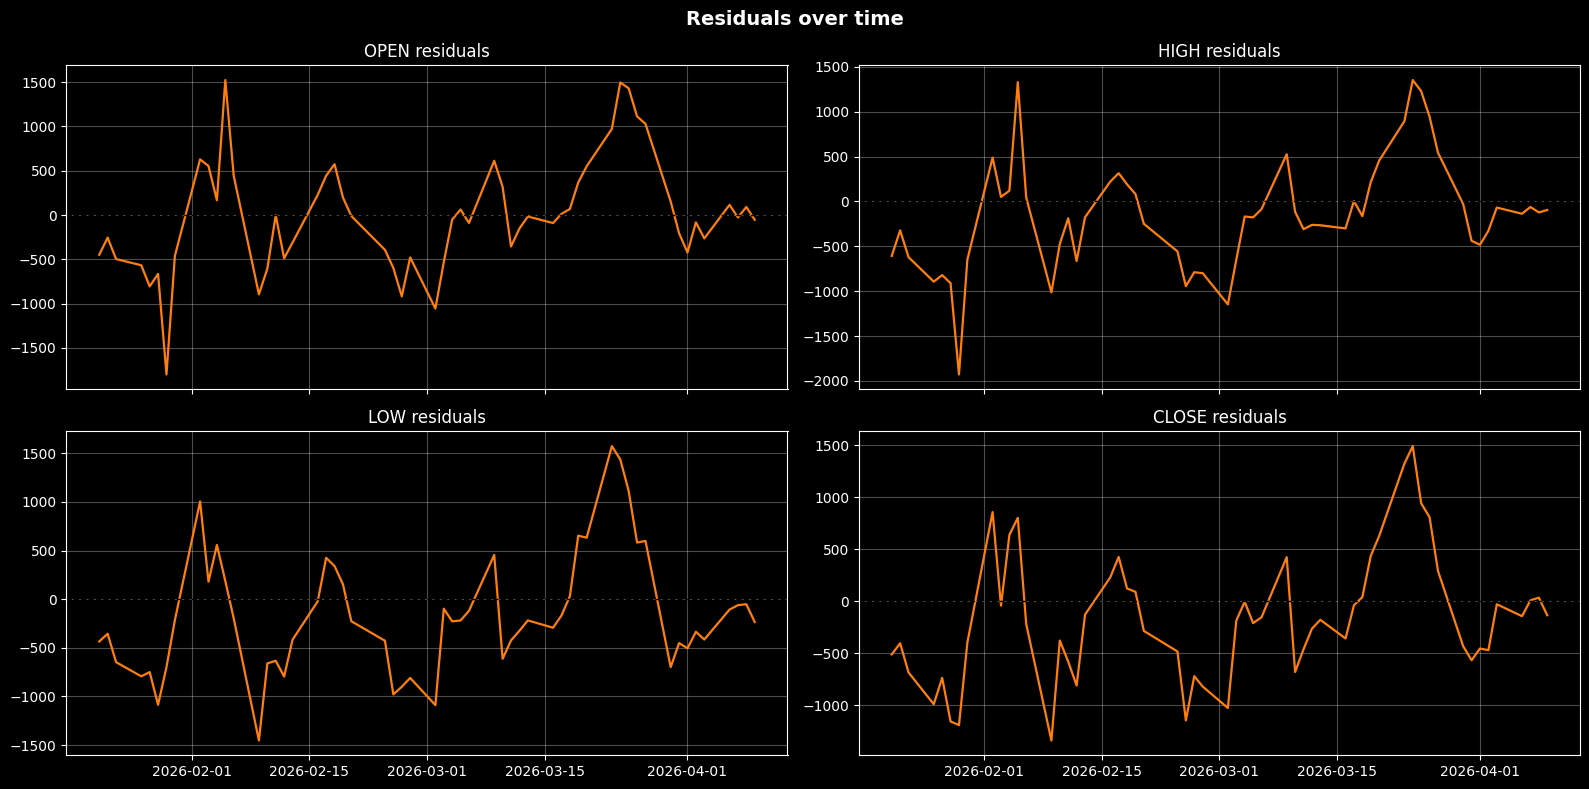

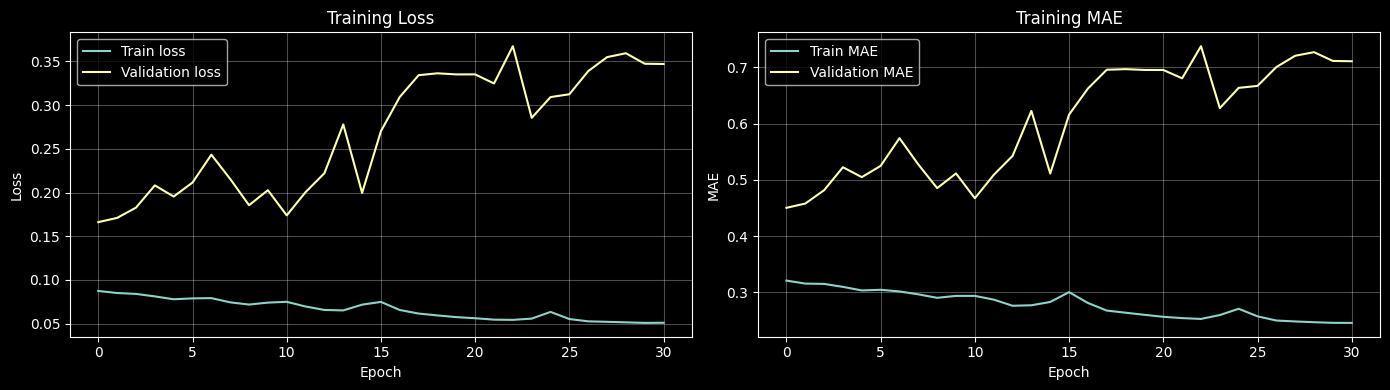


--- Results for SLIVER ---
Test metrics at +5 day horizon:
open   | MAE:  16.7535 | RMSE:  22.9661 | R2:  0.0456 | Naive MAE:  17.0086 | Bias:  +0.3617
high   | MAE:  17.0847 | RMSE:  23.9704 | R2:  0.0679 | Naive MAE:  17.7307 | Bias:  -0.5534
low    | MAE:  15.8208 | RMSE:  20.9288 | R2:  0.0287 | Naive MAE:  15.8116 | Bias:  +3.5734
close  | MAE:  17.4303 | RMSE:  23.5402 | R2: -0.0229 | Naive MAE:  17.4668 | Bias:  +3.5296


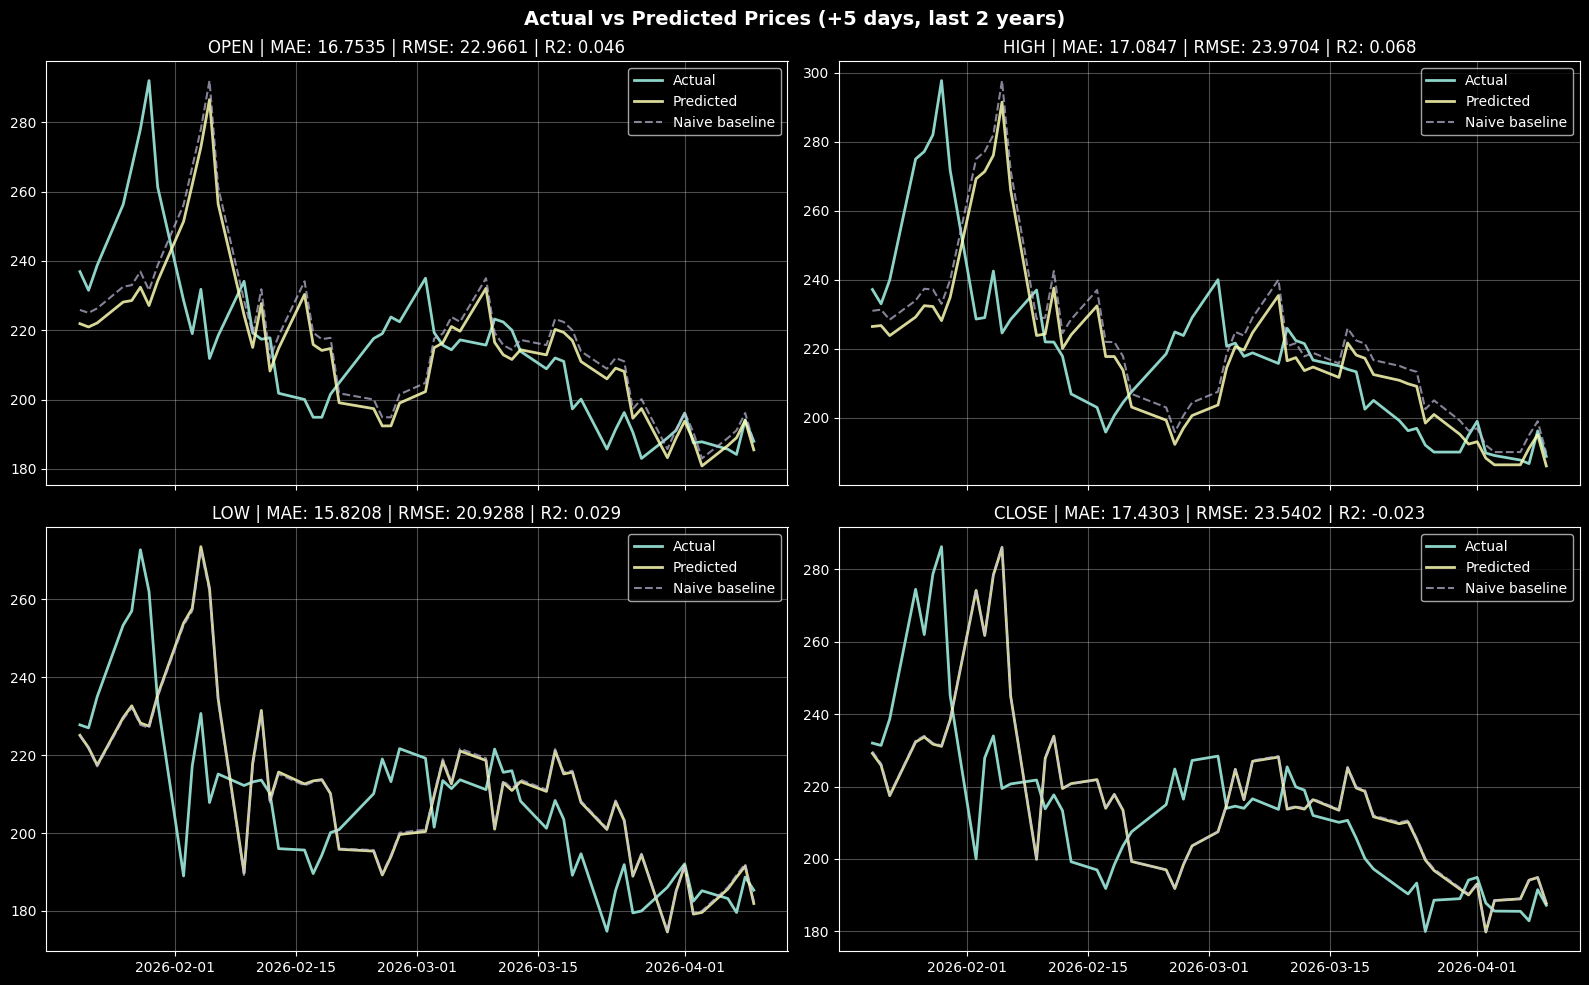

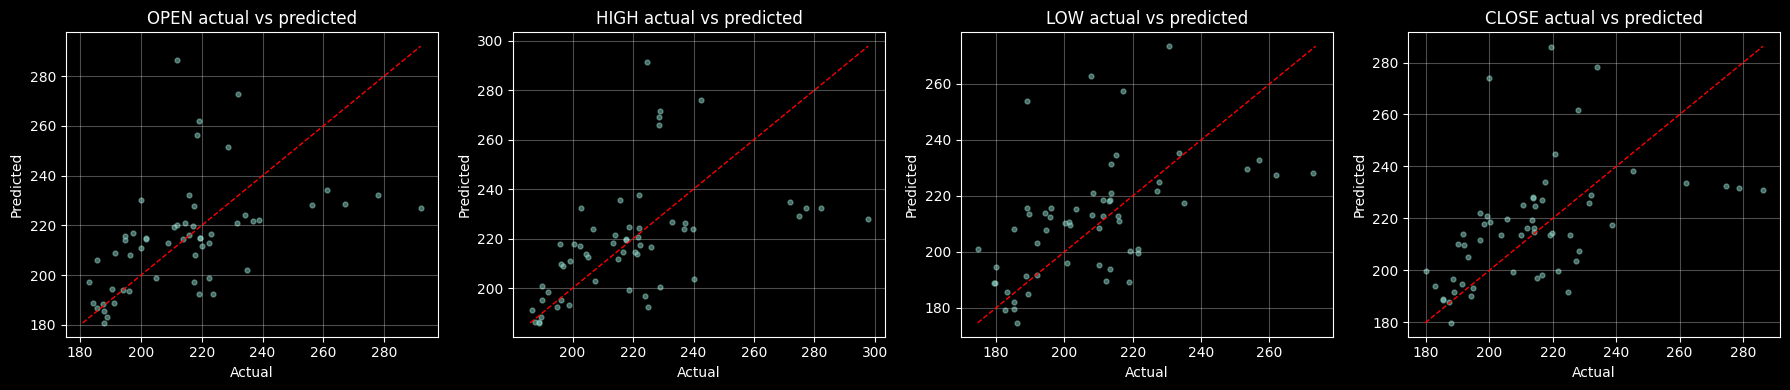

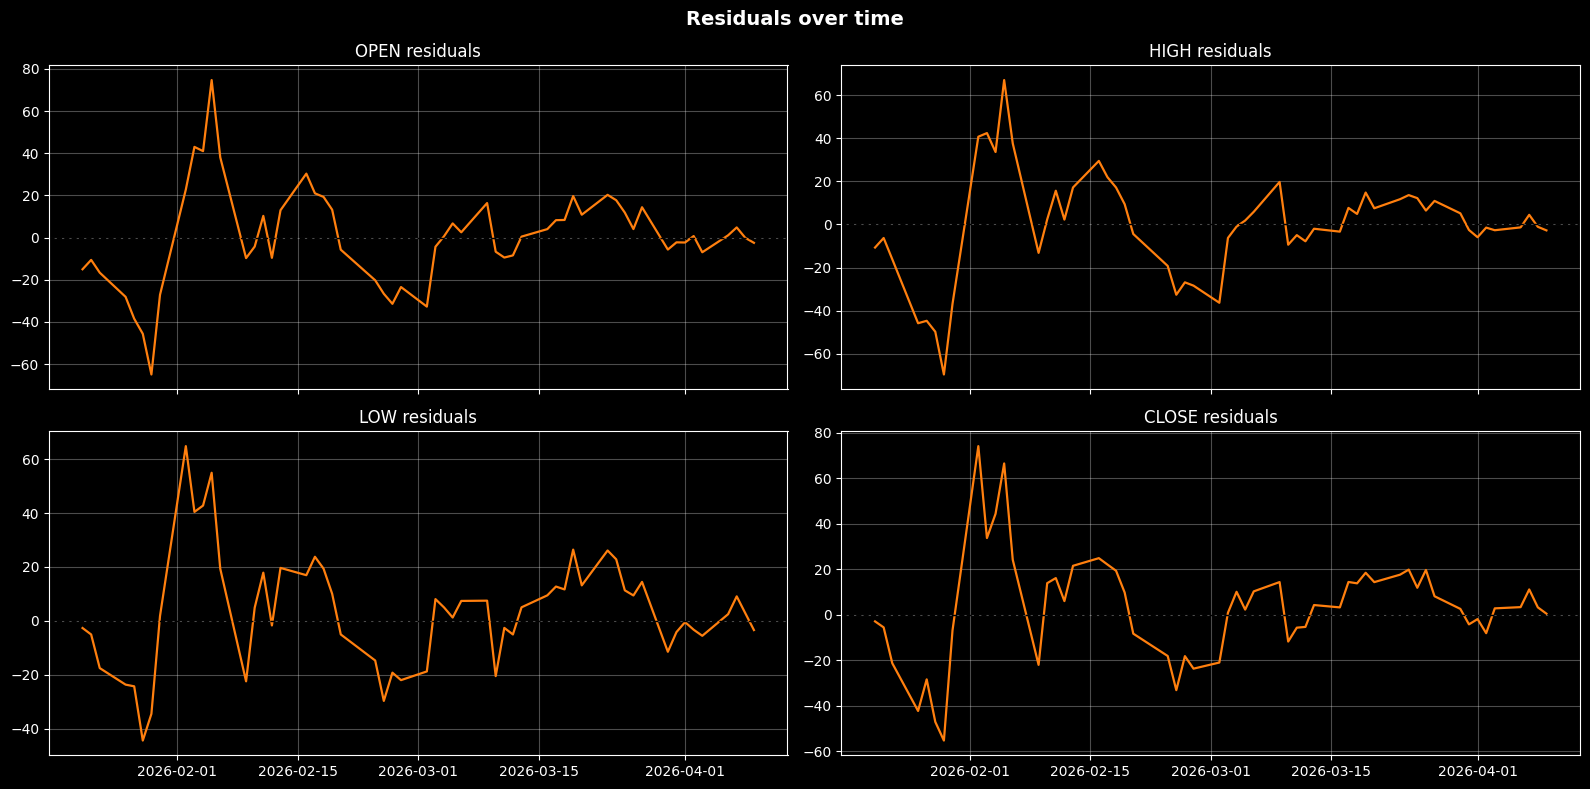

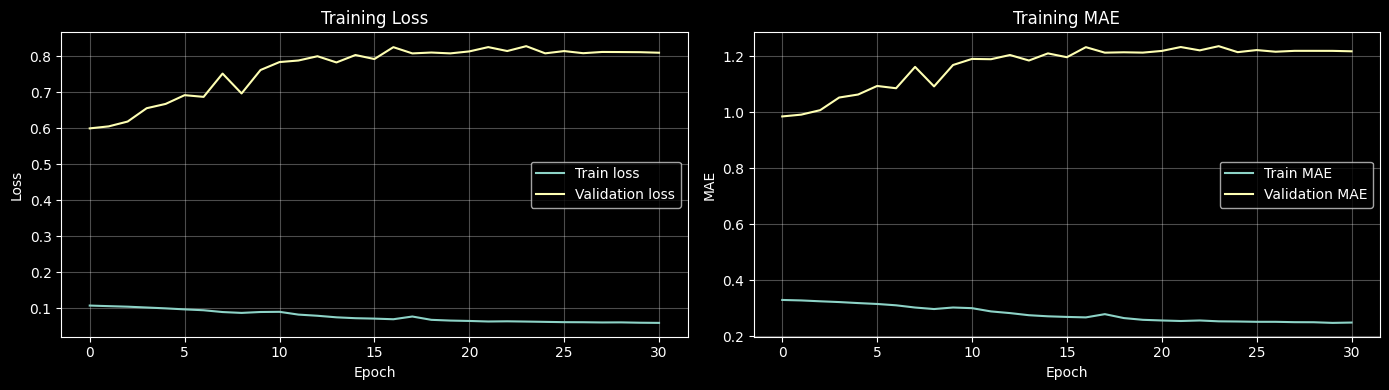


--- Results for COPPER ---
Test metrics at +5 day horizon:
open   | MAE: 461.3813 | RMSE: 540.8462 | R2: -4.0210 | Naive MAE: 251.2143 | Bias: +445.2965
high   | MAE: 403.5458 | RMSE: 493.5693 | R2: -1.5034 | Naive MAE: 295.0893 | Bias: +319.3130
low    | MAE: 296.8229 | RMSE: 349.0272 | R2: -1.2204 | Naive MAE: 283.2321 | Bias: +116.2317
close  | MAE: 314.4459 | RMSE: 378.9967 | R2: -1.0129 | Naive MAE: 266.3393 | Bias: +196.9079


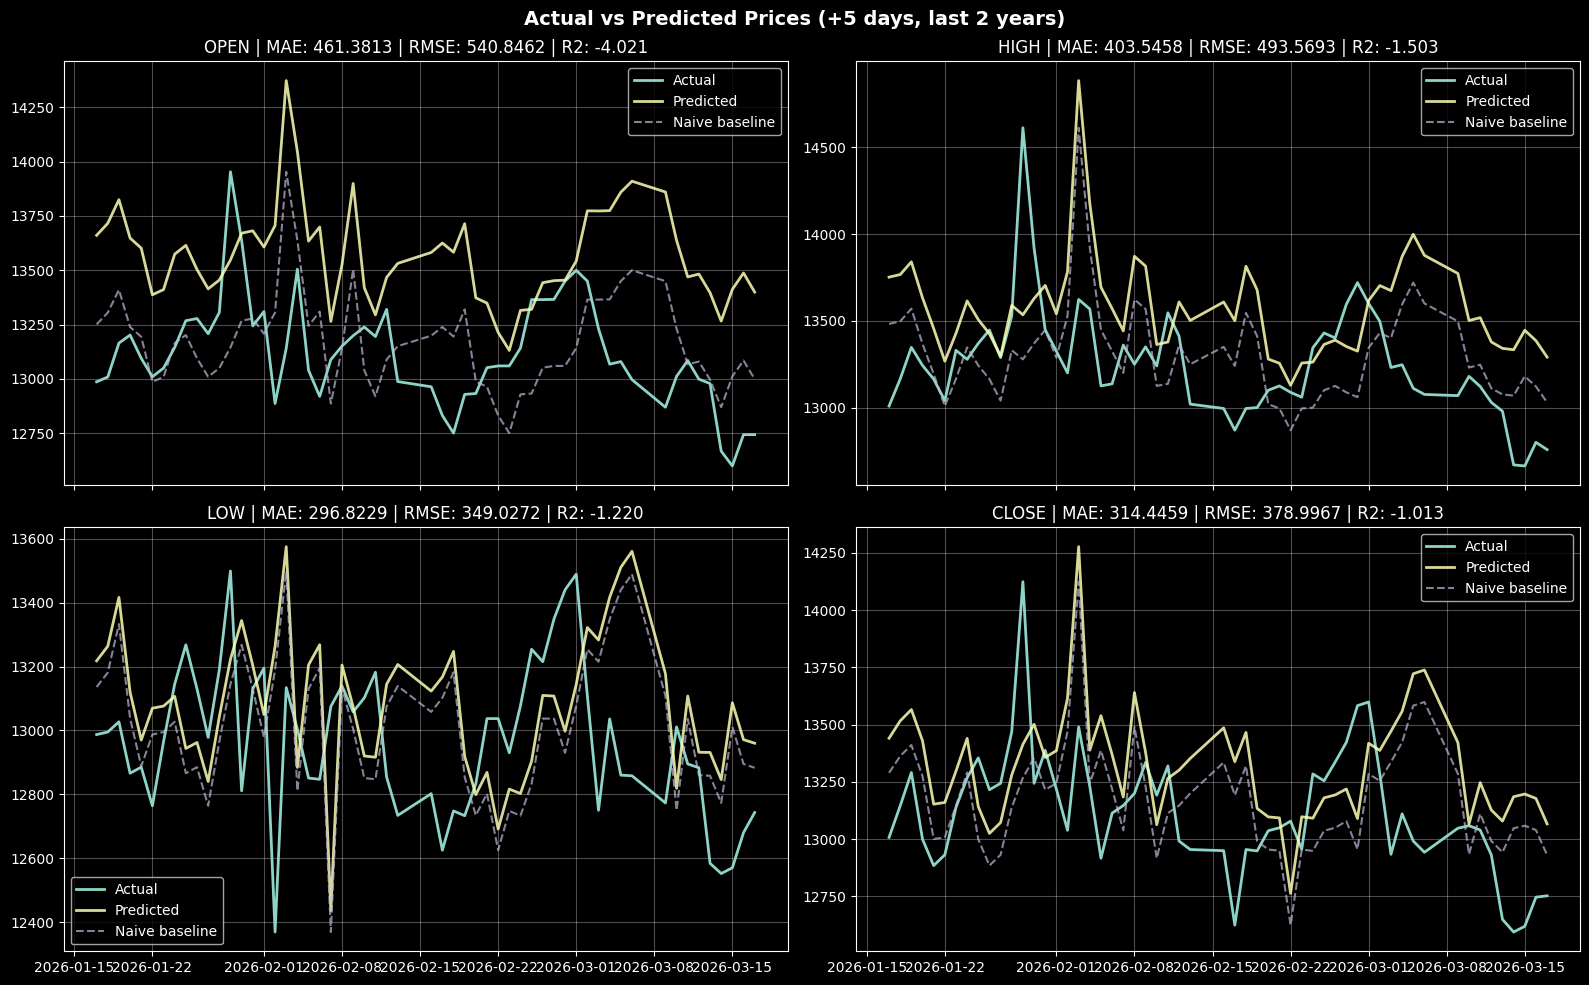

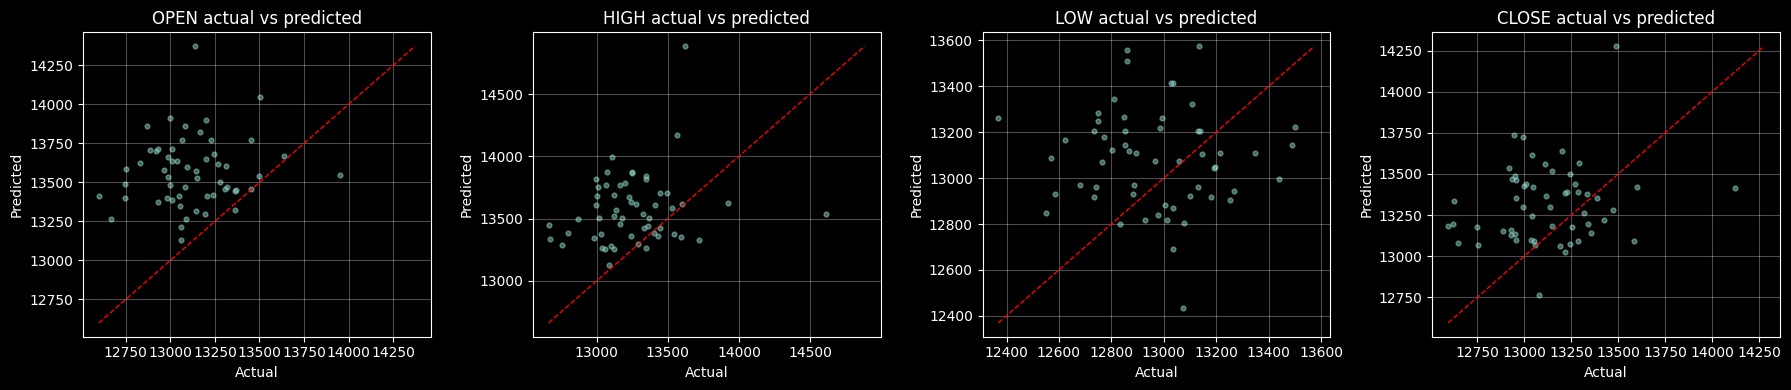

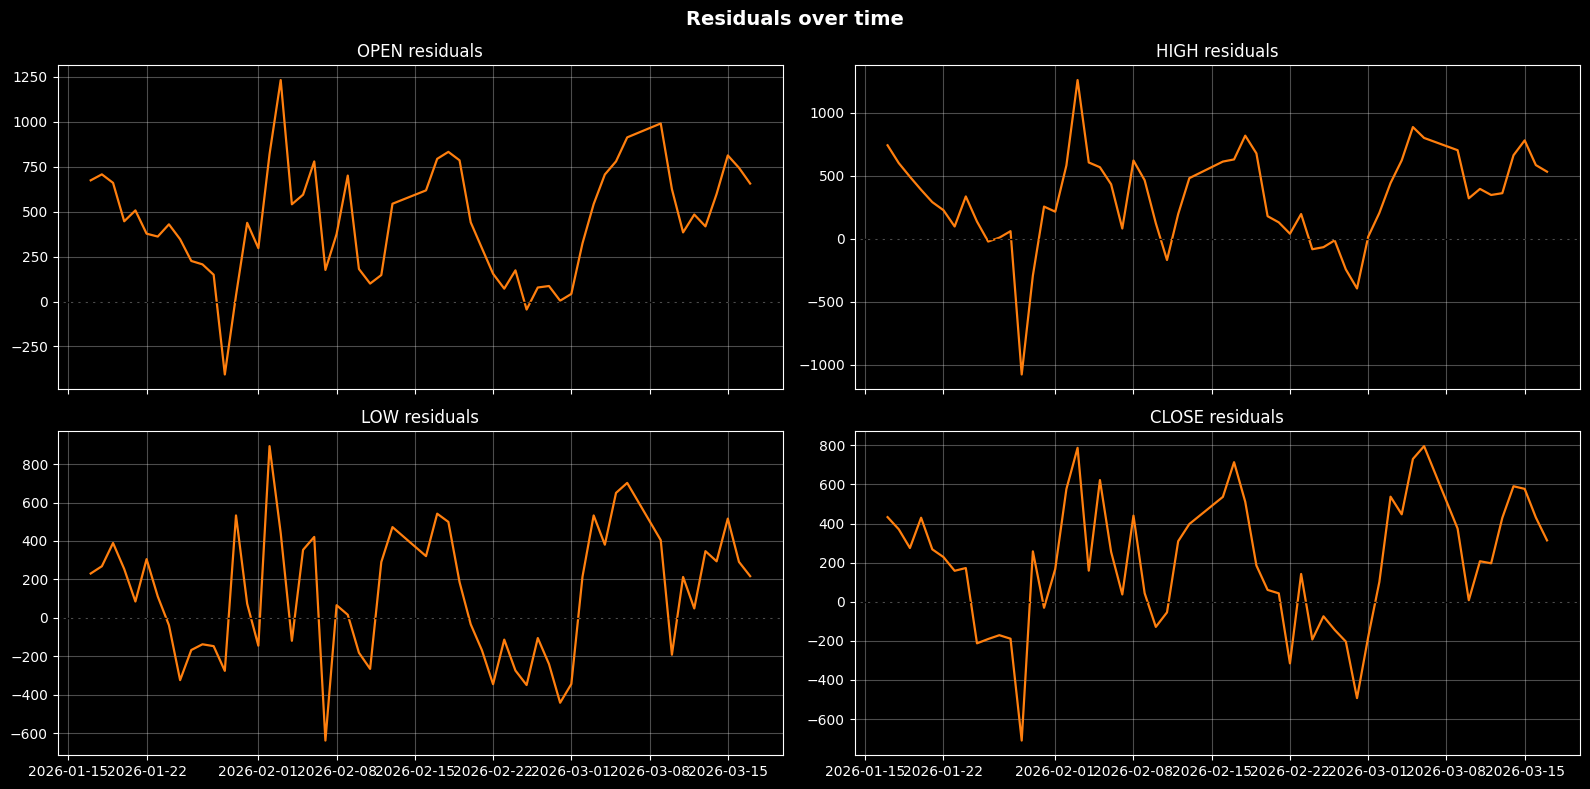

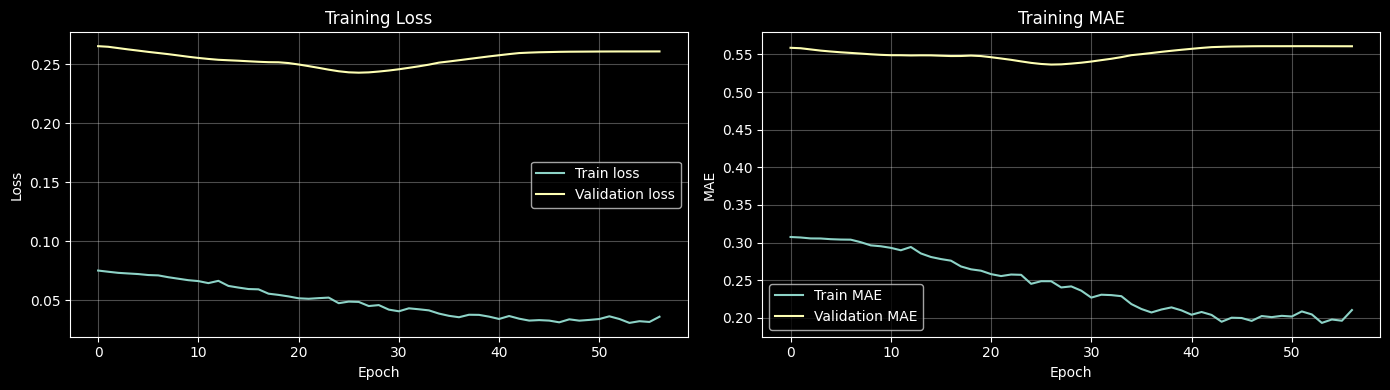

In [9]:
def plot_results(model, history, x_scaler, y_scaler, X_test, y_test, base_test, test_dates, feature_columns=None, target_columns=None, horizon=5):
    if feature_columns is None:
        feature_columns = [
            "open", "high", "low", "close", "volume", "sentiment",
            "hl_range", "oc_change", "close_return", "close_return_3", "close_return_5",
            "ma_close_5", "ma_close_10", "ma_close_20", "volatility_5", "volatility_10",
            "price_momentum_5", "price_momentum_10", "sentiment_ma_3", "sentiment_ma_7"
        ]
    if target_columns is None:
        target_columns = ["open", "high", "low", "close"]

    num_targets = len(target_columns)
    pred_scaled = model.predict(X_test, verbose=0)

    pred_relative = y_scaler.inverse_transform(pred_scaled.reshape(-1, num_targets)).reshape(-1, horizon, num_targets)
    y_test_relative = y_scaler.inverse_transform(y_test.reshape(-1, num_targets)).reshape(-1, horizon, num_targets)

    base_real = np.asarray(base_test)
    pred_real = base_real[:, None, :] * (1.0 + pred_relative)
    y_test_real = base_real[:, None, :] * (1.0 + y_test_relative)
    last_known_real = base_real

    day_idx = horizon - 1
    metrics = {}
    print(f"Test metrics at +{horizon} day horizon:")
    signed_bias = (pred_real[:, day_idx, :] - y_test_real[:, day_idx, :]).mean(axis=0)

    for i, col in enumerate(target_columns):
        mae = mean_absolute_error(y_test_real[:, day_idx, i], pred_real[:, day_idx, i])
        rmse = np.sqrt(mean_squared_error(y_test_real[:, day_idx, i], pred_real[:, day_idx, i]))
        r2 = r2_score(y_test_real[:, day_idx, i], pred_real[:, day_idx, i])
        naive_mae = mean_absolute_error(y_test_real[:, day_idx, i], last_known_real[:, i])
        metrics[col] = {"mae": mae, "rmse": rmse, "r2": r2, "naive_mae": naive_mae}
        print(
            f"{col:6} | MAE: {mae:8.4f} | RMSE: {rmse:8.4f} | "
            f"R2: {r2:7.4f} | Naive MAE: {naive_mae:8.4f} | Bias: {signed_bias[i]:+8.4f}"
        )

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
    fig.suptitle(f"Actual vs Predicted Prices (+{horizon} days, last 2 years)", fontsize=14, fontweight="bold")

    for idx, col in enumerate(target_columns):
        ax = axes[idx // 2, idx % 2]
        ax.plot(test_dates, y_test_real[:, day_idx, idx], label="Actual", linewidth=2)
        ax.plot(test_dates, pred_real[:, day_idx, idx], label="Predicted", linewidth=2, alpha=0.85)
        ax.plot(test_dates, last_known_real[:, idx], label="Naive baseline", linestyle="--", alpha=0.7)
        ax.set_title(f"{col.upper()} | MAE: {metrics[col]['mae']:.4f} | RMSE: {metrics[col]['rmse']:.4f} | R2: {metrics[col]['r2']:.3f}")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for idx, col in enumerate(target_columns):
        ax = axes[idx]
        ax.scatter(y_test_real[:, day_idx, idx], pred_real[:, day_idx, idx], alpha=0.5, s=12)
        lims = [
            min(y_test_real[:, day_idx, idx].min(), pred_real[:, day_idx, idx].min()),
            max(y_test_real[:, day_idx, idx].max(), pred_real[:, day_idx, idx].max()),
        ]
        ax.plot(lims, lims, "r--", linewidth=1)
        ax.set_title(f"{col.upper()} actual vs predicted")
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    residuals = pred_real[:, day_idx, :] - y_test_real[:, day_idx, :]
    fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
    fig.suptitle("Residuals over time", fontsize=14, fontweight="bold")
    for idx, col in enumerate(target_columns):
        ax = axes[idx // 2, idx % 2]
        ax.plot(test_dates, residuals[:, idx], color="tab:orange", linewidth=1.6)
        ax.axhline(0, color="black", linewidth=1, linestyle="--")
        ax.set_title(f"{col.upper()} residuals")
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(history.history["loss"], label="Train loss")
    ax1.plot(history.history["val_loss"], label="Validation loss")
    ax1.set_ylabel("Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_title("Training Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history["mae"], label="Train MAE")
    ax2.plot(history.history["val_mae"], label="Validation MAE")
    ax2.set_ylabel("MAE")
    ax2.set_xlabel("Epoch")
    ax2.set_title("Training MAE")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


for metal, info in trained_models.items():
    print(f"\n--- Results for {metal.upper()} ---")
    plot_results(
        info["model"],
        info["history"],
        info["x_scaler"],
        info["y_scaler"],
        info["X_test"],
        info["y_test"],
        info["base_test"],
        info["test_dates"],
        target_columns=info["target_columns"],
        horizon=info["horizon"],
    )